<a href="https://colab.research.google.com/github/muhammad-rhakan/summer-project/blob/main/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA DICTIONARY
----
### Datetime
*   Timestamp — Date and time of the recorded data point

### Continuous
*   `LIT101` — Level Indicator Transmitter at stage
*   `FIT101` — Flow Indicator Transmitter at stage
*   `FIT201` — Flow Indicator Transmitter at stage 2
*   `FIT301`, `LIT301` — Flow and Level indicators at stage 3
*   `FIT401`, `LIT401` — Flow and Level indicators at stage 4
*   `FIT501`, `FIT502`, `FIT503`, `FIT504` — Flow indicators at stage 5
*   `FIT601` — Flow Indicator Transmitter at stage 6
*   `AIT201`, `AIT202`, `AIT203` — Analyzer Indicators for pH, conductivity, and ORP at stage 2
*   `AIT401`, `AIT402` — Analyzer Indicators at stage 4
*   `AIT501`, `AIT502`, `AIT503`, `AIT504` — Analyzer Indicators at stage 5
*   `DPIT301` — Differential Pressure Indicator Transmitter at stage 3
*   `PIT501`, `PIT502`, `PIT503` — Pressure Indicator Transmitters at stage 5

### Discrete
*   `MV101` — Motorized Valve at stage 1
*   `MV201` — Motorized Valve at stage 2
*   `MV301`, `MV302`, `MV303`, `MV304` — Motorized Valves at stage 3
*   `P101`, `P102` — Pumps at stage 1
*   `P201`, `P202`, `P203`, `P204`, `P205`, `P206` — Pumps at stage 2
*   `P301`, `P302` — Pumps at stage 3
*   `P401`, `P402`, `P403`, `P404` — Pumps at stage 4
*   `P501`, `P502` — Pumps at stage 5
*   `P601`, `P602`, `P603` — Pumps at stage 6
*   `UV401` — UV disinfection unit

### Binary
*   `Normal/Attack` — Label indicating whether the data point corresponds to normal or attack operation

In [ ]:
import kagglehub
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from kagglehub import KaggleDatasetAdapter
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
def preprocessing(data):
    # Fix titles
    data.columns = data.columns.str.strip()

    # Repair time format and set index
    data['Timestamp'] = data['Timestamp'].str.strip()
    data['Timestamp'] = pd.to_datetime(data['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
    data = data.sort_values('Timestamp', ascending=True)
    data = data.drop_duplicates().dropna()
    data = data.reset_index(drop=True)

    # Encode target feature
    target = 'Normal/Attack'
    data[target] = data[target].map({'Normal':0, 'Attack':1})

    return data

# Execude function
df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")
data_complete = preprocessing(df)

# data_complete[[col for col in data_complete.columns if data_complete[col].nunique() == 1]].describe().T

/tmp/ipykernel_1582/1077640182.py:19: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "vishala28/swat-dataset-secure-water-treatment-system","merged.csv")


100%|██████████| 407M/407M [00:11<00:00, 36.2MB/s]


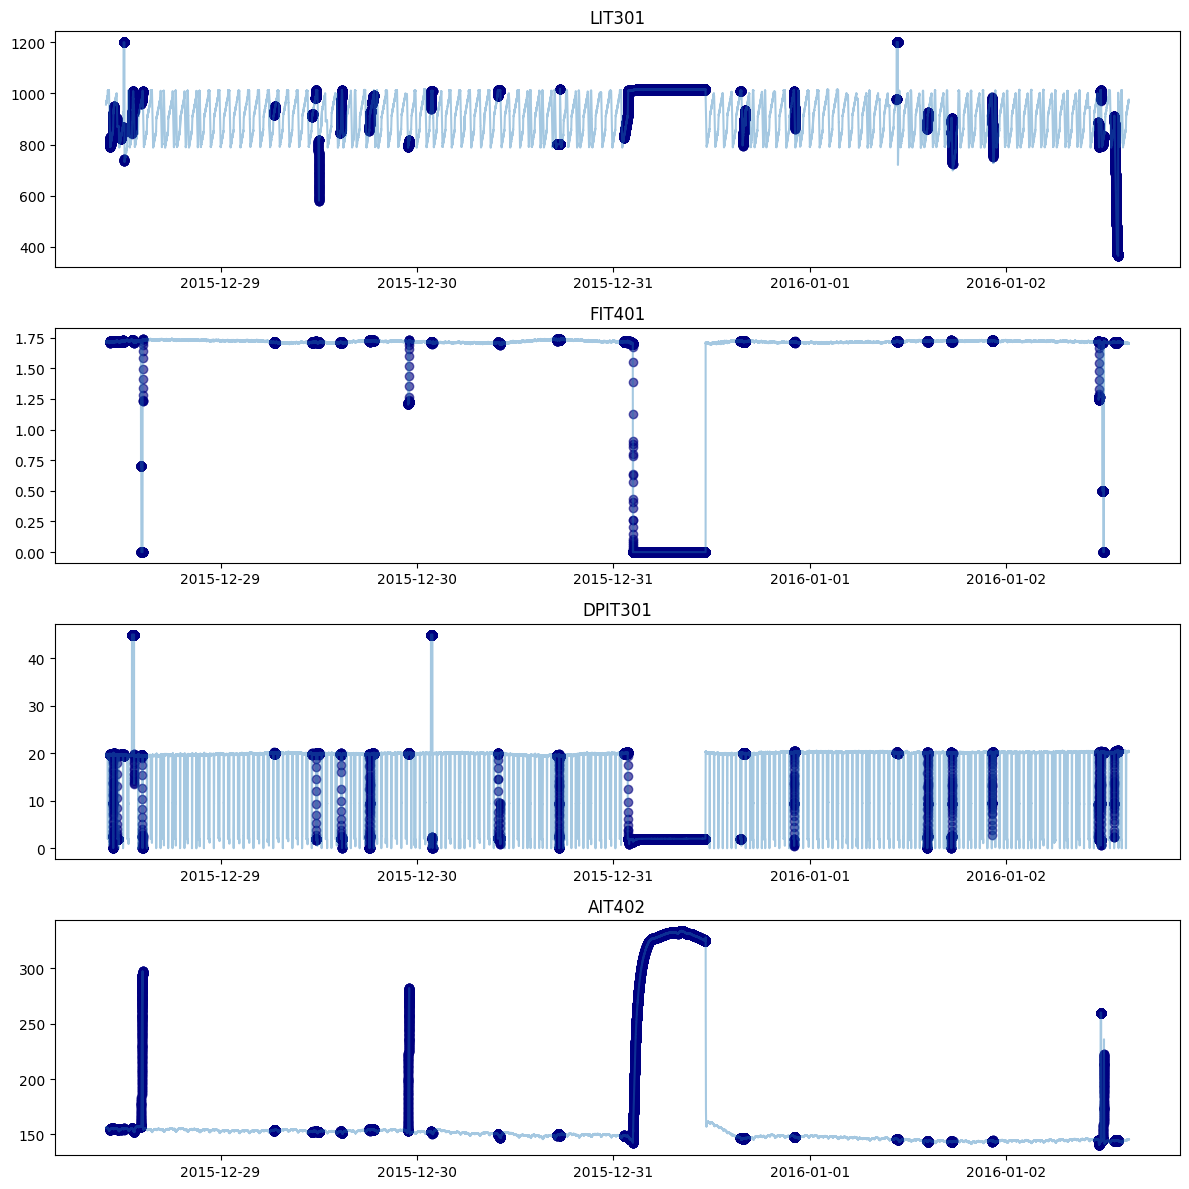

In [ ]:
def easy_visualizations(data):
    columns = ['LIT301', 'FIT401', 'DPIT301', 'AIT402']
    fig, axs = plt.subplots(4, 1, figsize=(12,12))

    for i, col in enumerate(columns):
        axs[i].plot(data['Timestamp'], data[col], alpha=0.4)
        axs[i].scatter(data[data['Normal/Attack'] == 1]['Timestamp'], data[data['Normal/Attack'] == 1][col], color='navy', alpha=0.6)
        axs[i].set_title(col)

    plt.tight_layout()
    plt.show()


# Execute cell
easy_visualizations(data_complete)

In [ ]:
def heatmap(data):
    # Calculate the correlation matrix
    matrix = data.corr()

    # Create the dynamic Plotly heatmap
    fig = px.imshow(
        matrix,
        text_auto=False,               # Set to True if you want to display the values inside the cells
        zmin=-1,
        zmax=1,
        labels=dict(color="Correlation"), # Label for the color bar
        width=800,                    # Adjust size as needed for your layout
        height=800
    )

    # Update layout to keep it square and clean
    fig.update_layout(
        xaxis_title=None,
        yaxis_title=None,
        yaxis_autorange='reversed'     # Prevents the y-axis from being flipped upside down
    )

    fig.update_xaxes(tickangle=90)
    fig.show()

heatmap(data_complete)

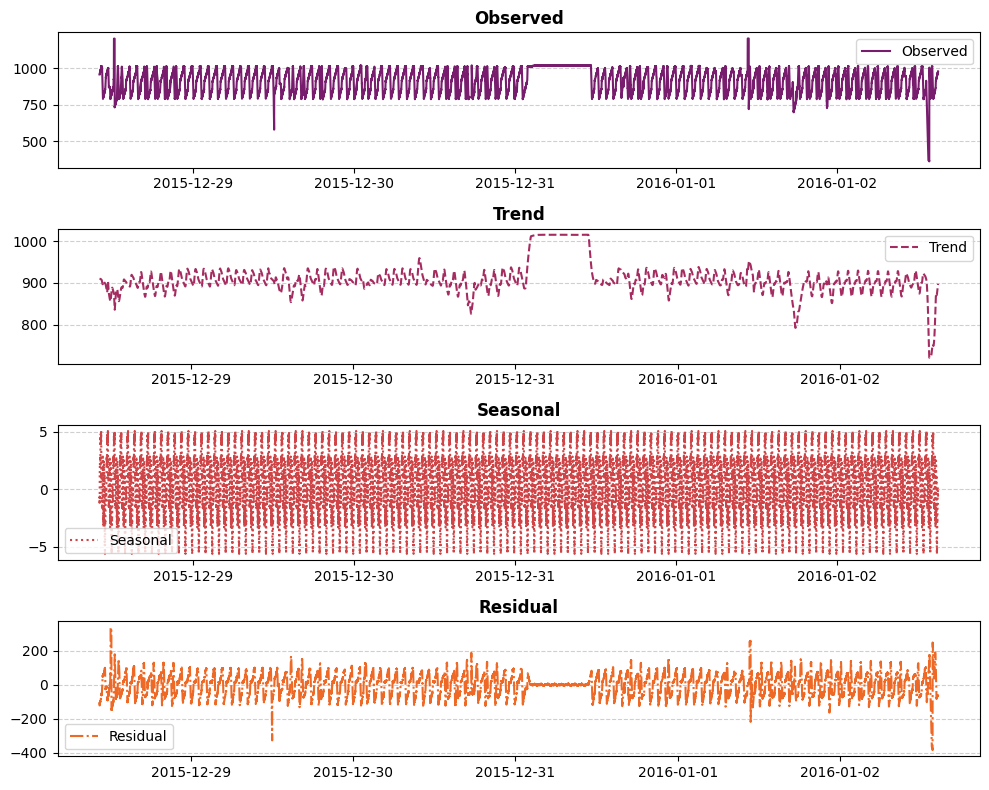

In [ ]:
def decompose(df, feature):
    series = df[['Timestamp', feature]].set_index('Timestamp', drop=True)

    result = seasonal_decompose(series, model='additive', period=3600)
    components = {
        'Observed': result.observed,
        'Trend': result.trend,
        'Seasonal': result.seasonal,
        'Residual': result.resid}

    colors = ['#781c6d', '#a52c60', '#cf4446', '#ed6925']
    line_styles = ['-', '--', ':', '-.']

    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=False)
    for ax, (label, data), color, style in zip(axes, components.items(), colors, line_styles):
        ax.plot(data, label=label, color=color, linestyle=style)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()


decompose(data_complete, 'LIT301')

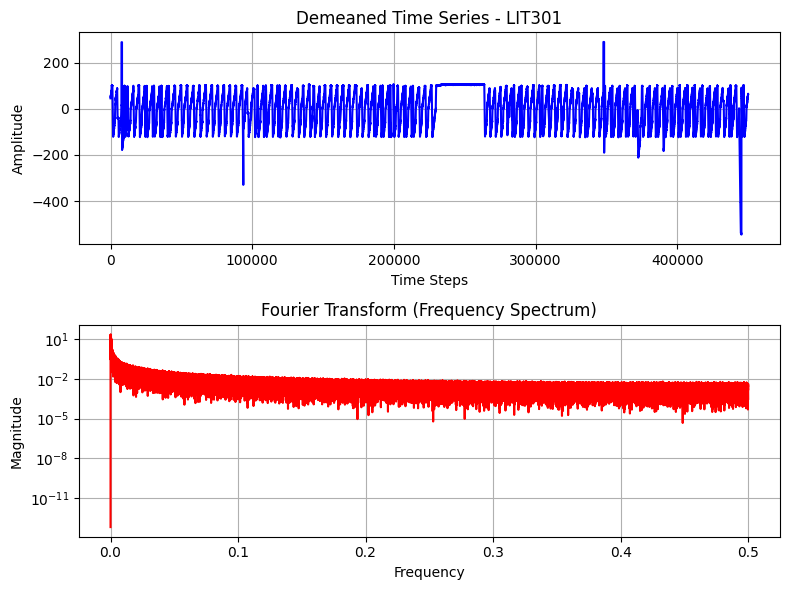

In [ ]:
from numpy.fft import fft, fftfreq

def fourier_transform(df, feature, sampling_rate=1.0):
    series = df[['Timestamp', feature]].set_index('Timestamp', drop=True)
    series_dm = np.array(series).flatten() - np.mean(np.array(series)) # flattened to 1D array

    N = len(series_dm)
    fft_output = fft(series_dm)
    frequencies = fftfreq(N, d=1/sampling_rate)

    # 3. Take positive frequencies (since FFT is symmetric)
    half_N = N // 2
    pos_frequencies = frequencies[:half_N]
    # Normalize magnitude
    magnitude = np.abs(fft_output)[:half_N] * (2.0 / N)

    # 4. Plotting
    fig, axes = plt.subplots(2, 1, figsize=(8, 6))

    # Plot 1: Demeaned Time-Series Signal
    axes[0].plot(series_dm, color='blue')
    axes[0].set_title(f"Demeaned Time Series - {feature}")
    axes[0].set_xlabel("Time Steps")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True)

    # Plot 2: FFT Frequency Spectrum
    axes[1].semilogy(pos_frequencies, magnitude, color='red')
    axes[1].set_title("Fourier Transform (Frequency Spectrum)")
    axes[1].set_yscale('log')
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Magnitude")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


# To call it (assuming 'data_complete' is your DataFrame):
fourier_transform(data_complete, 'LIT301', sampling_rate=1.0)

In [ ]:
!pip install PyWavelets

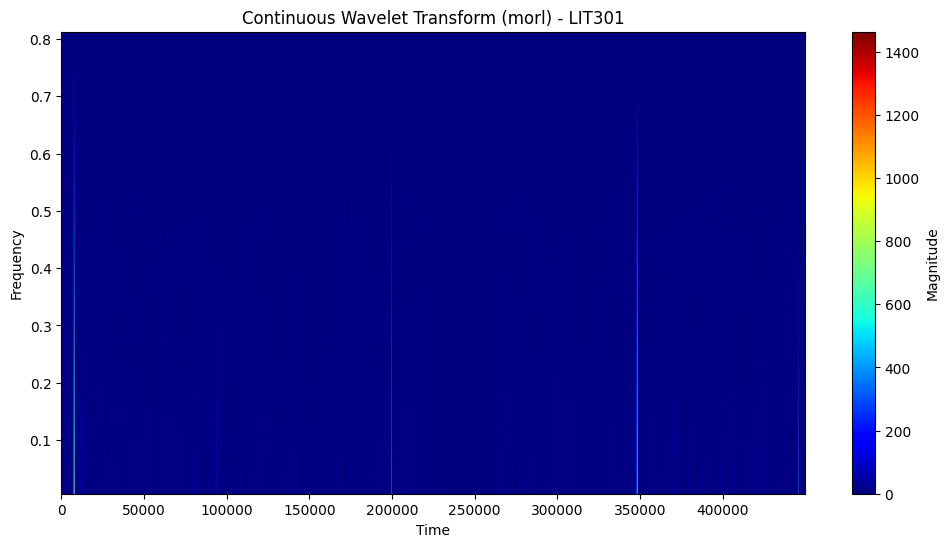

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt


def wavelet_transform(df, feature, sampling_rate=1.0,
                      wavelet='morl', max_scale=128):
    """
    Continuous Wavelet Transform visualization.

    Parameters
    ----------
    df : pandas.DataFrame
    feature : str
        Column name.
    sampling_rate : float
        Samples per second (or per time unit).
    wavelet : str
        Wavelet name (default: Morlet).
    max_scale : int
        Maximum scale to analyze.
    """

    signal = df[feature].values

    # Remove DC trend
    signal = signal - np.mean(signal)

    scales = np.arange(1, max_scale)

    coefficients, frequencies = pywt.cwt(
        signal,
        scales,
        wavelet,
        sampling_period=1 / sampling_rate
    )

    plt.figure(figsize=(12, 6))

    plt.imshow(
        np.abs(coefficients),
        extent=[0, len(signal), frequencies[-1], frequencies[0]],
        aspect='auto',
        cmap='jet'
    )

    plt.colorbar(label='Magnitude')
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.title(f"Continuous Wavelet Transform ({wavelet}) - {feature}")

    plt.show()


wavelet_transform(
    data_complete,
    "LIT301",
    sampling_rate=1.0,
    wavelet='morl',
    max_scale=128
)

Number of PCs exceeding threshold: 16

Total variance explained  0.9541548635448468


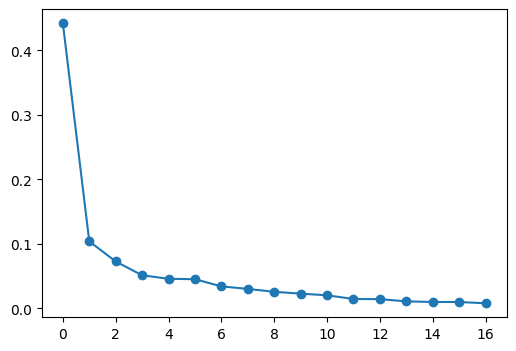

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def feature_decomposition(data, scaler, pca):
    df = data.set_index('Timestamp', drop=True)
    df = df.drop(columns='Normal/Attack')

    scaled = scaler.fit_transform(df)
    transformed = pca.fit_transform(scaled)

    num_pc = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
    explained_ratio = np.sum(pca.explained_variance_ratio_[0:num_pc])

    print(f'Number of PCs exceeding threshold: {num_pc}\n')
    print(f"Total variance explained  {explained_ratio}")

    plt.figure(figsize=(6,4))
    plt.plot(np.arange(num_pc+1), pca.explained_variance_ratio_[:num_pc+1], 'o-')
    plt.show()


scaler = StandardScaler()
pca = PCA(whiten=True)

samples, features = data_complete.shape
train = int(samples * 0.7)
val = int(samples * 0.15)

X_train = data_complete[:train]
X_val = data_complete[train:train+val]
X_test = data_complete[train+val:]

# Execute function: select whole data or train set only
feature_decomposition(X_train, scaler, pca)